In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from xgboost import XGBRegressor

In [2]:
df = pd.read_csv("household_power.csv", delimiter = ';')
df.head()

/tmp/ipykernel_43534/1159580387.py:1: DtypeWarning: Columns (0: Global_active_power, 1: Global_reactive_power, 2: Voltage, 3: Global_intensity, 4: Sub_metering_1, 5: Sub_metering_2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("household_power.csv", delimiter = ';')


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [3]:
df.dtypes

Date                         str
Time                         str
Global_active_power       object
Global_reactive_power     object
Voltage                   object
Global_intensity          object
Sub_metering_1            object
Sub_metering_2            object
Sub_metering_3           float64
dtype: object

In [4]:
df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"])

/tmp/ipykernel_43534/3174756210.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"])


In [5]:
df["hour"] = df["datetime"].dt.hour
df["day"] = df["datetime"].dt.day
df["day_of_week"] = df["datetime"].dt.dayofweek
df["month"] = df["datetime"].dt.month
df["year"] = df["datetime"].dt.year
df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)

In [6]:
df.dtypes

Date                                str
Time                                str
Global_active_power              object
Global_reactive_power            object
Voltage                          object
Global_intensity                 object
Sub_metering_1                   object
Sub_metering_2                   object
Sub_metering_3                  float64
datetime                 datetime64[us]
hour                              int32
day                               int32
day_of_week                       int32
month                             int32
year                              int32
is_weekend                        int64
dtype: object

In [7]:
cols = [
"Global_active_power",
"Global_reactive_power",
"Voltage",
"Global_intensity",
"Sub_metering_1",
"Sub_metering_2"
]

for c in cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

In [8]:
df.dtypes

Date                                str
Time                                str
Global_active_power             float64
Global_reactive_power           float64
Voltage                         float64
Global_intensity                float64
Sub_metering_1                  float64
Sub_metering_2                  float64
Sub_metering_3                  float64
datetime                 datetime64[us]
hour                              int32
day                               int32
day_of_week                       int32
month                             int32
year                              int32
is_weekend                        int64
dtype: object

In [9]:
df = df.ffill()
df.isna().sum()

Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
datetime                 0
hour                     0
day                      0
day_of_week              0
month                    0
year                     0
is_weekend               0
dtype: int64

In [10]:
df["total_sub_metering"] = (
    df["Sub_metering_1"] +
    df["Sub_metering_2"] +
    df["Sub_metering_3"]
)

In [11]:
df[["total_sub_metering", "Sub_metering_1", "Sub_metering_2", "Sub_metering_3"]].head()

,total_sub_metering,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,18.0,0.0,1.0,17.0
1,17.0,0.0,1.0,16.0
2,19.0,0.0,2.0,17.0
3,18.0,0.0,1.0,17.0
4,18.0,0.0,1.0,17.0


In [12]:
df.dtypes

Date                                str
Time                                str
Global_active_power             float64
Global_reactive_power           float64
Voltage                         float64
Global_intensity                float64
Sub_metering_1                  float64
Sub_metering_2                  float64
Sub_metering_3                  float64
datetime                 datetime64[us]
hour                              int32
day                               int32
day_of_week                       int32
month                             int32
year                              int32
is_weekend                        int64
total_sub_metering              float64
dtype: object

In [13]:
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'])

In [14]:
df["other_energy"] = (
    df["Global_active_power"]*1000/60 - df["total_sub_metering"]
)

In [15]:
df["other_energy"].head()

0    52.266667
1    72.333333
2    70.566667
3    71.800000
4    43.100000
Name: other_energy, dtype: float64

In [16]:
df["lag_1"] = df["Global_active_power"].shift(1)
df["lag_60"] = df["Global_active_power"].shift(60)
df["lag_1440"] = df["Global_active_power"].shift(1440)

In [17]:
df[['lag_1', 'lag_60', 'lag_1440']].head(5)

,lag_1,lag_60,lag_1440
0,NaN,NaN,NaN
1,4.216,NaN,NaN
2,5.360,NaN,NaN
3,5.374,NaN,NaN
4,5.388,NaN,NaN


In [18]:
df["rolling_mean_10"] = df["Global_active_power"].rolling(10).mean()
df["rolling_std_10"] = df["Global_active_power"].rolling(10).std()

In [19]:
df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)

In [20]:
df = df.drop(["Date","Time","datetime"], axis=1)

In [21]:
df.to_csv('light_data.csv')

In [22]:
y = df["Global_active_power"]
X = df.drop(["Global_active_power", "Global_intensity", "lag_1", "other_energy"], axis=1)

In [23]:
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

In [24]:
split = int(len(df)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [25]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [ ]:
model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("RMSE:", rmse)    
print(f'R²: {r2:.3f}')

RMSE: 0.1760485238703602
R²: 0.960


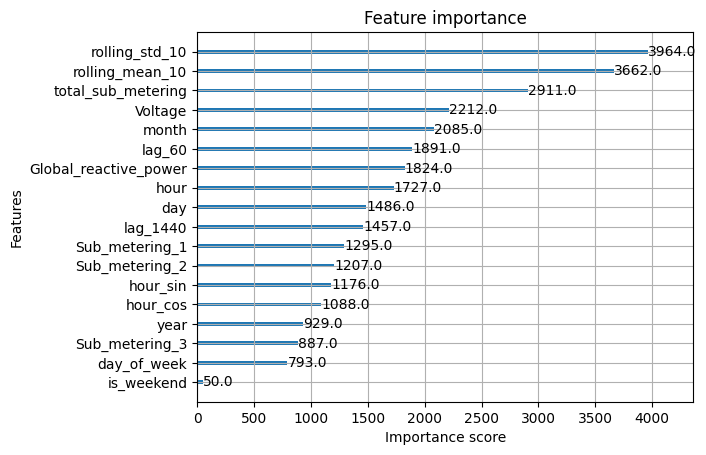

In [ ]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# XGBRegressor.plot_importance(model)
# print(model.feature_importances_)
# plt.show()
# plt.bar(range(len(model.feature_importances_)), model.feature_importances_)
plot_importance(model)
plt.show()

In [ ]:
import joblib

joblib.dump(model, "xgboost_energy_model.pkl")

['xgboost_energy_model.pkl']